# Smart Infusion Pump Fault Tree Analysis (FTA)
#
This notebook presents a medium-level case study of a Smart Infusion Pump using Fault Tree Analysis (FTA). The purpose is to model how bothcybersecurity-related failures and normal technical failures can combine to cause an unsafe medication delivery event.

# The implementation includes: #
1. A fault tree node structure
2. Gate probability calculations
3. Gate-by-gate probability evaluation
4. MOCUS cut set generation
5. MICSUP minimal cut set generation
6. Fault tree visualization
7. Result interpretation

# In this case study, the top event is: #
**"Unsafe medication delivery"**
#
# The analysis mixes:
- security events such as spoofing and alert suppression
- non-security events such as motor fault and battery failure


# Importing Required Libraries

In [1]:
from dataclasses import dataclass, field
from itertools import product
import networkx as nx
import matplotlib.pyplot as plt

# Core Fault Tree Node Structure
#
 This section defines the main data structure used in the fault tree.
# Each node can represent either: #
 - a BASIC event
 - an AND gate
 - an OR gate

 BASIC events contain a probability value.
 Gate nodes contain child nodes.

In [2]:
# Main node structure for the fault tree
@dataclass
class FTNode:
    name: str
    node_type: str              # BASIC, AND, OR
    prob: float = None          # used only for basic events
    children: list = field(default_factory=list)

# Probability Helper Functions
#
# Fault tree logic uses gate mathematics:
# AND gate:
 The output occurs only when all input events occur together.
 So, the probabilities are multiplied.

# OR gate:
The output occurs when at least one input event occurs.
So, the complement rule is used.

 These helper functions will be used later in gate-by-gate evaluation.

In [14]:
# Function to calculate probability of an AND gate
def and_gate_prob(probs):
    # Initialize result to 1 because AND uses multiplication
    result = 1.0

    # Loop through each input probability
    for p in probs:
        # Multiply all probabilities together (P = p1 * p2 * ... * pn)
        result *= p

    # Return final AND gate probability
    return result


# Function to calculate probability of an OR gate
def or_gate_prob(probs):
    # Initialize result to 1 for complement multiplication
    result = 1.0

    # Loop through each input probability
    for p in probs:
        # Multiply complements of probabilities (1 - p)
        result *= (1 - p)

    # Final OR probability = 1 - product of complements
    return 1 - result

# Cut Set Reduction Utilities

A cut set is a combination of basic events that can cause the top event.
#
#Some cut sets may be repeated or may contain unnecessary extra events.
# For example:
{A, B} and {A, B, C}

Since {A, B} is already enough, {A, B, C} is not minimal.
#
# The function below removes:
- duplicate cut sets
- supersets of already smaller cut sets

In [15]:
# Function to remove duplicate cut sets and non-minimal supersets
def minimize_cut_sets(cut_sets):
    # List to store final minimal (unique) cut sets
    unique = []

    # Temporary list to store unique sets using frozenset (hashable)
    temp = []

    # Loop through each cut set in input
    for cs in cut_sets:
        # Convert set to frozenset so it can be compared and stored
        f = frozenset(cs)

        # Add only if it is not already present (removes duplicates)
        if f not in temp:
            temp.append(f)

    # Sort cut sets:
    # First by size (smaller sets first)
    # Then lexicographically for consistency
    temp = sorted(temp, key=lambda s: (len(s), sorted(list(s))))

    # Loop through sorted cut sets
    for cs in temp:
        # Flag to check if current set is a superset of any already selected set
        is_superset = False

        # Compare with already selected minimal sets
        for kept in unique:
            # If an existing set is a subset of current set
            # then current set is NOT minimal
            if kept.issubset(cs):
                is_superset = True
                break

        # If not a superset, keep it as minimal
        if not is_superset:
            unique.append(cs)

    # Convert frozensets back to normal sets before returning
    return [set(x) for x in unique]

# Lookup Table Builder
#
During MOCUS expansion, the program needs quick access to a node
based on its name. For that purpose, a dictionary is created:

{ node_name : node_object }

 This helps while expanding rows in top-down cut set generation.

In [16]:
# Function to build a lookup dictionary for all nodes in the fault tree
def build_node_lookup(root):
    # Initialize an empty dictionary to store node_name : node_object
    lookup = {}

    # Define a recursive Depth-First Search (DFS) function
    def dfs(node):
        # Add the current node to the dictionary
        # Key = node name, Value = node object
        lookup[node.name] = node

        # Traverse all child nodes of the current node
        for child in node.children:
            # Recursively call dfs on each child
            dfs(child)

    # Start DFS traversal from the root node
    dfs(root)

    # Return the completed lookup dictionary
    return lookup

# Gate-by-Gate Probability Evaluation
#
This section evaluates the fault tree recursively.

# Working:
- If the node is BASIC, its probability is directly used.
- If the node is AND, child probabilities are multiplied. - If the node is OR, the OR-gate formula is applied.

# The function also stores:
- probability of each node
- step-by-step evaluation details

 This is useful for explanation and reporting.

In [18]:
# Function to recursively compute probability for every node in the fault tree
def evaluate_probabilities(node, verbose=True, results=None, steps=None):

    # Initialize dictionary to store node probabilities if not provided
    if results is None:
        results = {}

    # Initialize list to store step-by-step evaluation details
    if steps is None:
        steps = []

    # -------- CASE 1: BASIC EVENT --------
    if node.node_type == "BASIC":

        # Store probability of the basic event in results dictionary
        results[node.name] = node.prob

        # Store step details for reporting
        steps.append({
            "node": node.name,          # name of the node
            "type": "BASIC",            # node type
            "inputs": "-",              # no inputs for basic event
            "probability": node.prob    # assigned probability
        })

        # If verbose mode is ON, print details
        if verbose:
            print(f"[BASIC EVENT] {node.name}")
            print(f"  Assigned Probability = {node.prob:.6f}\n")

        # Return probability, updated results, and steps
        return node.prob, results, steps


    # CASE 2: GATE NODE (AND / OR)

    # Lists to store child probabilities and names
    child_probs = []
    child_names = []

    # Recursively evaluate all child nodes first
    for child in node.children:

        # Recursive call to evaluate each child
        p, results, steps = evaluate_probabilities(
            child,
            verbose=verbose,
            results=results,
            steps=steps
        )

        # Store returned probability
        child_probs.append(p)

        # Store child node name
        child_names.append(child.name)


    # COMPUTE GATE OUTPUT

    # If node is AND gate → multiply probabilities
    if node.node_type == "AND":
        node_prob = and_gate_prob(child_probs)

    # If node is OR gate → use OR formula
    elif node.node_type == "OR":
        node_prob = or_gate_prob(child_probs)

    # Handle invalid node type
    else:
        raise ValueError(f"Unknown node type: {node.node_type}")


    # -------- STORE RESULT --------

    # Save computed probability for current node
    results[node.name] = node_prob

    # Save step details for reporting
    steps.append({
        "node": node.name,                      # node name
        "type": node.node_type,                 # AND / OR
        "inputs": ", ".join(child_names),       # input node names
        "probability": node_prob                # computed probability
    })


    # PRINT OUTPUT (IF VERBOSE)

    if verbose:
        print(f"[{node.node_type} GATE] {node.name}")

        # Show input node names
        print(f"  Inputs : {', '.join(child_names)}")

        # Show input probability values
        print(f"  Values : {', '.join([f'{p:.6f}' for p in child_probs])}")

        # Show final computed result
        print(f"  Result : P = {node_prob:.6f}\n")


    # Return computed probability along with updated structures
    return node_prob, results, steps

# MOCUS Method
#
MOCUS is a top-down cut set generation method.
# Idea:
- Start from the top event
- Expand one non-basic node at a time
- OR gate creates separate rows
- AND gate puts all children in the same row

 Expansion continues until only BASIC events remain.

Then the cut sets are minimized.

In [19]:
# Function to generate cut sets using the MOCUS (top-down) method
def mocus_cut_sets(root):

    # Build a lookup dictionary for quick access to nodes by name
    lookup = build_node_lookup(root)

    # Start with the top event as the initial row
    # Each row represents a possible cut set (initially only the top event)
    rows = [[root.name]]

    # Flag to track whether further expansion is needed
    changed = True

    # Continue expanding until no non-basic nodes remain
    while changed:

        # Assume no changes in this iteration
        changed = False

        # Store updated rows after expansion
        new_rows = []

        # Process each current row
        for row in rows:

            # Flag to check if expansion happened in this row
            expanded = False

            # Loop through elements in the row
            for i, event_name in enumerate(row):

                # Get the corresponding node object
                node = lookup[event_name]

                # If BASIC event, no expansion needed
                if node.node_type == "BASIC":
                    continue

                # Found a non-basic node → expansion will happen
                expanded = True
                changed = True

                # OR GATE EXPANSION
                if node.node_type == "OR":

                    # For OR, create separate rows for each child
                    for child in node.children:

                        # Replace the current node with one child
                        new_row = row[:i] + [child.name] + row[i+1:]

                        # Add new row to list
                        new_rows.append(new_row)

                # AND GATE EXPANSION
                elif node.node_type == "AND":

                    # For AND, replace node with ALL its children in same row
                    new_row = row[:i] + [child.name for child in node.children] + row[i+1:]

                    # Add new row to list
                    new_rows.append(new_row)

                # Expand only one node at a time per row (important for MOCUS)
                break

            # If no expansion happened (row contains only BASIC events)
            if not expanded:
                new_rows.append(row)

        # Update rows for next iteration
        rows = new_rows


    # FINAL PROCESSING

    # Convert each row into a set (to remove duplicates inside row)
    cut_sets = [set(row) for row in rows]

    # Remove duplicate and non-minimal cut sets
    minimal = minimize_cut_sets(cut_sets)

    # Return:
    # 1. All generated cut sets
    # 2. Minimal cut sets
    return cut_sets, minimal

# MICSUP Method
#
MICSUP works in a bottom-up recursive way.
#
# Rules:
- BASIC event -> returns its own singleton set
- OR gate -> union of child cut sets
- AND gate -> cartesian product of child cut sets
#
 After combining, cut sets are minimized.

This method is useful to verify the MOCUS results.

In [21]:
# Function to generate minimal cut sets using MICSUP (bottom-up approach)
def micsup_cut_sets(node):

    #  BASE CASE: BASIC EVENT
    # If the node is a basic event, return a single cut set containing only itself
    if node.node_type == "BASIC":
        return [set([node.name])]


    #  RECURSIVE STEP
    # Recursively compute cut sets for all child nodes
    # This creates a list where each element is a list of cut sets from a child
    child_cut_sets = [micsup_cut_sets(child) for child in node.children]


    #  OR GATE
    if node.node_type == "OR":

        # For OR gate, output cut sets are the union of all child cut sets
        combined = []

        # Loop through each child's cut sets
        for child_sets in child_cut_sets:

            # Add all cut sets from that child to combined list
            combined.extend(child_sets)

        # Remove duplicates and non-minimal supersets
        return minimize_cut_sets(combined)

    #  AND GATE
    elif node.node_type == "AND":

        # For AND gate, take cartesian product of child cut sets
        combined = []

        # Generate all combinations (one cut set from each child)
        for combo in product(*child_cut_sets):

            # Merge all sets in the combination into one set
            merged = set()

            for cs in combo:
                # Union operation to combine events
                merged |= cs

            # Add merged set to combined list
            combined.append(merged)

        # Remove duplicates and non-minimal supersets
        return minimize_cut_sets(combined)


    #  ERROR HANDLING
    else:
        # Raise error if node type is invalid
        raise ValueError(f"Unknown node type: {node.node_type}")

# Fault Tree Visualization
#

#To make the fault tree easier to understand, the tree is drawn using:
- NetworkX for graph structure
- Matplotlib for display

# Shape convention:
- circle  -> BASIC event
- square  -> AND gate
- diamond -> OR gate

This visual representation helps explain the logic of the case study.

In [22]:
# Function to recursively add nodes and edges into a NetworkX graph
def add_edges_to_graph(graph, node):

    # Add the current node to the graph with its attributes
    graph.add_node(node.name, node_type=node.node_type, prob=node.prob)

    # Loop through each child of the current node
    for child in node.children:

        # Add child node with its attributes
        graph.add_node(child.name, node_type=child.node_type, prob=child.prob)

        # Create a directed edge from parent node to child node
        graph.add_edge(node.name, child.name)

        # Recursively add edges for the child node
        add_edges_to_graph(graph, child)


# Function to compute hierarchical positions for nodes (top-down layout)
def hierarchy_pos(graph, root, width=2.4, vert_gap=0.18, vert_loc=0, xcenter=0.5, pos=None, parent=None):

    # Initialize position dictionary if not provided
    if pos is None:
        pos = {}

    # Assign position to current root node
    pos[root] = (xcenter, vert_loc)

    # Get all children (successors) of current node
    children = list(graph.successors(root))

    # Remove parent from children list to avoid going backward
    if parent is not None and parent in children:
        children.remove(parent)

    # If node has children, calculate positions for them
    if len(children) != 0:

        # Divide horizontal space among children
        dx = width / len(children)

        # Starting x-position for first child
        next_x = xcenter - width / 2 - dx / 2

        # Loop through each child
        for child in children:

            # Move to next horizontal position
            next_x += dx

            # Recursively assign positions to child nodes
            pos = hierarchy_pos(
                graph,
                child,
                width=dx,                    # reduce width for subtree
                vert_gap=vert_gap,           # vertical gap between levels
                vert_loc=vert_loc - vert_gap, # move downward
                xcenter=next_x,              # horizontal position for child
                pos=pos,
                parent=root                 # mark current node as parent
            )

    # Return dictionary of positions
    return pos


# Function to draw the fault tree using NetworkX and Matplotlib
def draw_fault_tree(root, title="Fault Tree"):

    # Create a directed graph
    G = nx.DiGraph()

    # Add all nodes and edges starting from root
    add_edges_to_graph(G, root)

    # Compute layout positions for visualization
    pos = hierarchy_pos(
        G,
        root.name,
        width=2.8,
        vert_gap=0.16,
        vert_loc=0,
        xcenter=0.5
    )

    # Separate nodes based on type for styling
    basic_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "BASIC"]
    and_nodes   = [n for n, d in G.nodes(data=True) if d["node_type"] == "AND"]
    or_nodes    = [n for n, d in G.nodes(data=True) if d["node_type"] == "OR"]

    # Create figure for plotting
    plt.figure(figsize=(18, 11))

    # Draw edges (connections between nodes)
    nx.draw_networkx_edges(G, pos, arrows=False, width=2)

    # Draw BASIC nodes (circle shape)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=basic_nodes,
        node_color="#dbeafe",   # light blue
        node_shape="o",         # circle
        node_size=3500,
        edgecolors="black",
        linewidths=1.5
    )

    # Draw AND gate nodes (square shape)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=and_nodes,
        node_color="#fde68a",   # yellow
        node_shape="s",         # square
        node_size=4000,
        edgecolors="black",
        linewidths=1.5
    )

    # Draw OR gate nodes (diamond shape)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=or_nodes,
        node_color="#fecaca",   # light red
        node_shape="D",         # diamond
        node_size=4000,
        edgecolors="black",
        linewidths=1.5
    )

    # Prepare labels for each node
    labels = {}

    for n, d in G.nodes(data=True):

        # If BASIC event → include probability in label
        if d["node_type"] == "BASIC":
            labels[n] = f"{n}\n[BASIC]\nP={d['prob']:.3f}"

        # If gate → show type only
        else:
            labels[n] = f"{n}\n[{d['node_type']} GATE]"

    # Draw labels on graph
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=8,
        font_weight="bold"
    )

    # Add title to the plot
    plt.title(title, fontsize=18, fontweight="bold")

    # Turn off axis for cleaner look
    plt.axis("off")

    # Adjust layout spacing
    plt.tight_layout()

    # Display the final fault tree
    plt.show()

# Reporting Utilities
#
This section contains helper functions used only for display and formatting.
#
# These functions print:
- section titles
- subsection titles
- probability summary table
- cut sets
- final interpretation

This improves readability of the final output.

In [23]:
# Function to print a main section title (used for major headings)
def print_section(title):

    # Print a blank line followed by a long separator line
    print("\n" + "=" * 90)

    # Print the given title
    print(title)

    # Print another separator line below the title
    print("=" * 90)


# Function to print a subsection title (smaller heading)
def print_subsection(title):

    # Print a blank line followed by dashed separator
    print("\n" + "-" * 90)

    # Print subsection title
    print(title)

    # Print closing dashed line
    print("-" * 90)


# Function to display probability values in table format
def print_probability_table(steps):

    # Print subsection heading
    print_subsection("Gate/Event Probability Summary")

    # Print table header with aligned columns
    print(f"{'No.':<5} {'Node Type':<12} {'Node Name':<45} {'Probability':>12}")

    # Print separator line
    print("-" * 90)

    # Loop through all steps (each node evaluation)
    for i, step in enumerate(steps, start=1):

        # Print each row with formatted alignment
        print(f"{i:<5} {step['type']:<12} {step['node'][:44]:<45} {step['probability']:>12.6f}")


# Function to print cut sets in structured form
def print_cut_sets(title, cut_sets):

    # Print subsection title
    print_subsection(title)

    # If no cut sets exist, print message and exit
    if not cut_sets:
        print("None")
        return

    # Print table header
    print(f"{'Set No.':<10} {'Order':<8} {'Cut Set'}")

    # Print separator
    print("-" * 90)

    # Loop through each cut set
    for i, cs in enumerate(cut_sets, start=1):

        # Convert set into sorted string format
        items = ", ".join(sorted(cs))

        # Print set number, order (size), and elements
        print(f"{i:<10} {len(cs):<8} {{{items}}}")


# Function to plot probability values as a bar chart
def plot_probability_summary(all_probs, case_name):

    # Extract node names and corresponding probabilities
    labels = list(all_probs.keys())
    values = list(all_probs.values())

    # Shorten long labels for better display
    labels_short = []
    for lbl in labels:

        # If label is too long, truncate it
        if len(lbl) > 28:
            labels_short.append(lbl[:25] + "...")

        # Otherwise keep original label
        else:
            labels_short.append(lbl)

    # Create figure for plotting
    plt.figure(figsize=(14, 7))

    # Draw bar chart
    plt.bar(range(len(values)), values)

    # Set x-axis labels with rotation
    plt.xticks(range(len(values)), labels_short, rotation=70, ha="right")

    # Label y-axis
    plt.ylabel("Probability")

    # Set plot title
    plt.title(f"Probability Summary: {case_name}", fontsize=15, fontweight="bold")

    # Add probability values on top of each bar
    for i, v in enumerate(values):
        plt.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=8)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()


# Function to print final interpretation of the case study
def print_case_study_interpretation(root, top_prob, minimal_cut_sets):

    # Print subsection heading
    print_subsection("Interpretation")

    # Print top event name
    print(f"Top Event: {root.name}")

    # Print computed probability
    print(f"Computed Top Event Probability: {top_prob:.6f}")

    # Print number of minimal cut sets
    print(f"Number of Minimal Cut Sets: {len(minimal_cut_sets)}")

    # Determine risk level based on probability value
    if top_prob < 0.05:
        level = "LOW to MODERATE"
    elif top_prob < 0.15:
        level = "MODERATE"
    else:
        level = "HIGH"

    # Print risk interpretation
    print(f"Risk Level Interpretation: {level}")

    # If minimal cut sets exist
    if minimal_cut_sets:

        # Find smallest cut set size
        smallest = min(len(cs) for cs in minimal_cut_sets)

        # Print smallest order
        print(f"Smallest Minimal Cut Set Order: {smallest}")

        # Print explanation
        print("This indicates the minimum number of basic failures required")
        print("to produce the top event under the current fault-tree structure.")

# Main Runner Function
#
This function executes the complete case study in one flow.
# It performs:
1. Fault tree drawing
2. Gate-by-gate probability evaluation
3. Top event result printing
4. Probability summary table
5. Probability plot
6. MOCUS cut sets
7. MICSUP cut sets
8. Consistency check
9. Final interpretation
#
This makes the notebook easy to run from a single call.

In [11]:
# Run the complete case study
def run_case_study(root, case_name):
    print_section(f"CASE STUDY: {case_name}")

    # draw tree
    print_subsection("Fault Tree Structure")
    draw_fault_tree(root, title=f"{case_name} - Fault Tree")

    # evaluate probabilities
    print_subsection("Gate-by-Gate Probability Analysis")
    top_prob, all_probs, steps = evaluate_probabilities(root, verbose=True)

    # print top event result
    print_section("TOP EVENT RESULT")
    print(f"Top Event Name        : {root.name}")
    print(f"Top Event Probability : {top_prob:.6f}")

    # print summary table
    print_probability_table(steps)

    # draw probability chart
    plot_probability_summary(all_probs, case_name)

    # mocus
    all_cut_sets_mocus, minimal_mocus = mocus_cut_sets(root)
    print_cut_sets("MOCUS - All Cut Sets", all_cut_sets_mocus)
    print_cut_sets("MOCUS - Minimal Cut Sets", minimal_mocus)

    # micsup
    minimal_micsup = micsup_cut_sets(root)
    print_cut_sets("MICSUP - Minimal Cut Sets", minimal_micsup)

    # compare both methods
    mocus_sorted = sorted([tuple(sorted(x)) for x in minimal_mocus])
    micsup_sorted = sorted([tuple(sorted(x)) for x in minimal_micsup])

    print_subsection("Consistency Check")
    print(f"MOCUS and MICSUP give the same minimal cut sets: {mocus_sorted == micsup_sorted}")

    # final interpretation
    print_case_study_interpretation(root, top_prob, minimal_mocus)

    return {
        "top_probability": top_prob,
        "all_probabilities": all_probs,
        "detailed_steps": steps,
        "mocus_all_cut_sets": all_cut_sets_mocus,
        "mocus_minimal_cut_sets": minimal_mocus,
        "micsup_minimal_cut_sets": minimal_micsup,
    }

# Smart Infusion Pump Case Study Definition
#
# In this case study, the top event is:
**"Unsafe medication delivery"**
#
# The fault tree includes:
#
# Security-related basic events:
- unauthorized dose parameter change
- wireless command spoofing
- alert suppression attack
#
# Non-security basic events:
- pump motor fault
- tubing blockage
- battery failure
 flow sensor calibration error
#
These are grouped through OR and AND gates to model how unsafe delivery can occur either through an overdose path or through pump failure conditions.

In [24]:
# Function to build the Smart Infusion Pump fault tree
def build_infusion_pump_case():


    # SECURITY-RELATED BASIC EVENTS

    # Basic event: unauthorized change in dose parameter
    unauthorized_dose_change = FTNode(
        name="Unauthorized dose parameter change",   # event name
        node_type="BASIC",                           # this is a basic event
        prob=0.02                                    # assigned probability
    )

    # Basic event: spoofed wireless command sent to pump
    wireless_command_spoofing = FTNode(
        name="Wireless command spoofing",            # event name
        node_type="BASIC",                           # basic event
        prob=0.015                                   # assigned probability
    )

    # Basic event: attack suppresses safety alerts
    alert_suppression_attack = FTNode(
        name="Alert suppression attack",             # event name
        node_type="BASIC",                           # basic event
        prob=0.01                                    # assigned probability
    )



    # NON-SECURITY BASIC EVENTS

    # Basic event: pump motor fails
    pump_motor_fault = FTNode(
        name="Pump motor fault",                     # event name
        node_type="BASIC",                           # basic event
        prob=0.03                                    # assigned probability
    )

    # Basic event: tubing is blocked
    tubing_blockage = FTNode(
        name="Tubing blockage",                      # event name
        node_type="BASIC",                           # basic event
        prob=0.025                                   # assigned probability
    )

    # Basic event: battery fails
    battery_failure = FTNode(
        name="Battery failure",                      # event name
        node_type="BASIC",                           # basic event
        prob=0.02                                    # assigned probability
    )

    # Basic event: flow sensor gives wrong reading due to calibration issue
    sensor_calibration_error = FTNode(
        name="Flow sensor calibration error",        # event name
        node_type="BASIC",                           # basic event
        prob=0.02                                    # assigned probability
    )



    # INTERMEDIATE EVENTS / GATES


    # OR gate:
    # incorrect dose command can happen if either unauthorized dose change
    # or wireless command spoofing occurs
    incorrect_dose_command = FTNode(
        name="Incorrect dose command issued",        # intermediate event name
        node_type="OR",                              # OR gate
        children=[unauthorized_dose_change, wireless_command_spoofing]  # input events
    )

    # OR gate:
    # unsafe delivery may go undetected if either alert suppression attack
    # or sensor calibration error happens
    delivery_not_detected = FTNode(
        name="Unsafe delivery not detected",         # intermediate event name
        node_type="OR",                              # OR gate
        children=[alert_suppression_attack, sensor_calibration_error]    # input events
    )

    # AND gate:
    # overdose path becomes active only when both
    # incorrect dose command and failure to detect unsafe delivery happen
    overdose_path = FTNode(
        name="Overdose path active",                 # intermediate event name
        node_type="AND",                             # AND gate
        children=[incorrect_dose_command, delivery_not_detected]         # input gates
    )

    # OR gate:
    # pump becomes unavailable or faulty if any one of these failures occurs
    pump_unavailable_or_faulty = FTNode(
        name="Pump unavailable or faulty",           # intermediate event name
        node_type="OR",                              # OR gate
        children=[pump_motor_fault, tubing_blockage, battery_failure]    # input events
    )



    # TOP EVENT


    # OR gate:
    # unsafe medication delivery can happen either because of overdose path
    # or because the pump is unavailable/faulty
    top_event = FTNode(
        name="Unsafe medication delivery",           # top event name
        node_type="OR",                              # OR gate
        children=[overdose_path, pump_unavailable_or_faulty]             # top-level causes
    )

    # Return the root node of the whole fault tree
    return top_event

# Running the Case Study
 The final block creates the fault tree and runs the complete analysis.
#
# The output will include:
- fault tree diagram
- gate-by-gate probabilities
- top event probability
- cut sets from MOCUS
- minimal cut sets from MICSUP
- consistency check
- final interpretation


CASE STUDY: Smart Infusion Pump - Security-Informed Safety

------------------------------------------------------------------------------------------
Fault Tree Structure
------------------------------------------------------------------------------------------


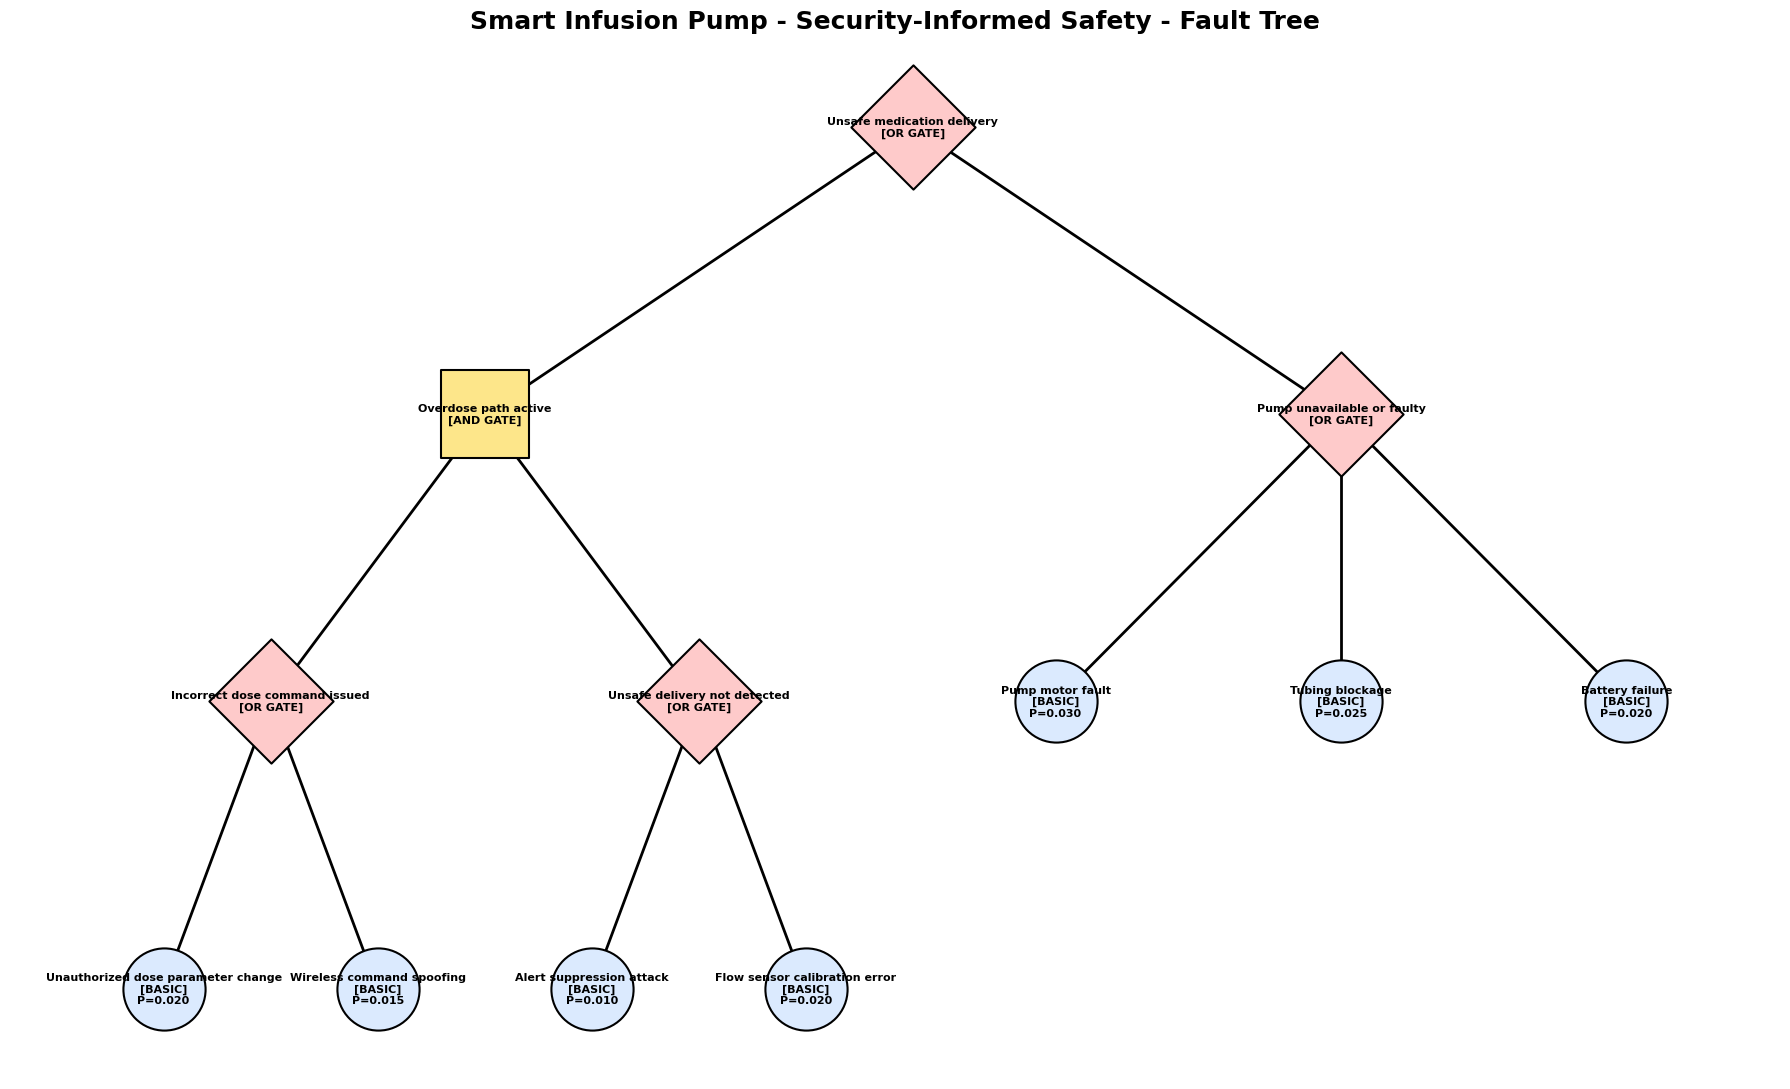


------------------------------------------------------------------------------------------
Gate-by-Gate Probability Analysis
------------------------------------------------------------------------------------------
[BASIC EVENT] Unauthorized dose parameter change
  Assigned Probability = 0.020000

[BASIC EVENT] Wireless command spoofing
  Assigned Probability = 0.015000

[OR GATE] Incorrect dose command issued
  Inputs : Unauthorized dose parameter change, Wireless command spoofing
  Values : 0.020000, 0.015000
  Result : P = 0.034700

[BASIC EVENT] Alert suppression attack
  Assigned Probability = 0.010000

[BASIC EVENT] Flow sensor calibration error
  Assigned Probability = 0.020000

[OR GATE] Unsafe delivery not detected
  Inputs : Alert suppression attack, Flow sensor calibration error
  Values : 0.010000, 0.020000
  Result : P = 0.029800

[AND GATE] Overdose path active
  Inputs : Incorrect dose command issued, Unsafe delivery not detected
  Values : 0.034700, 0.029800
  Result 

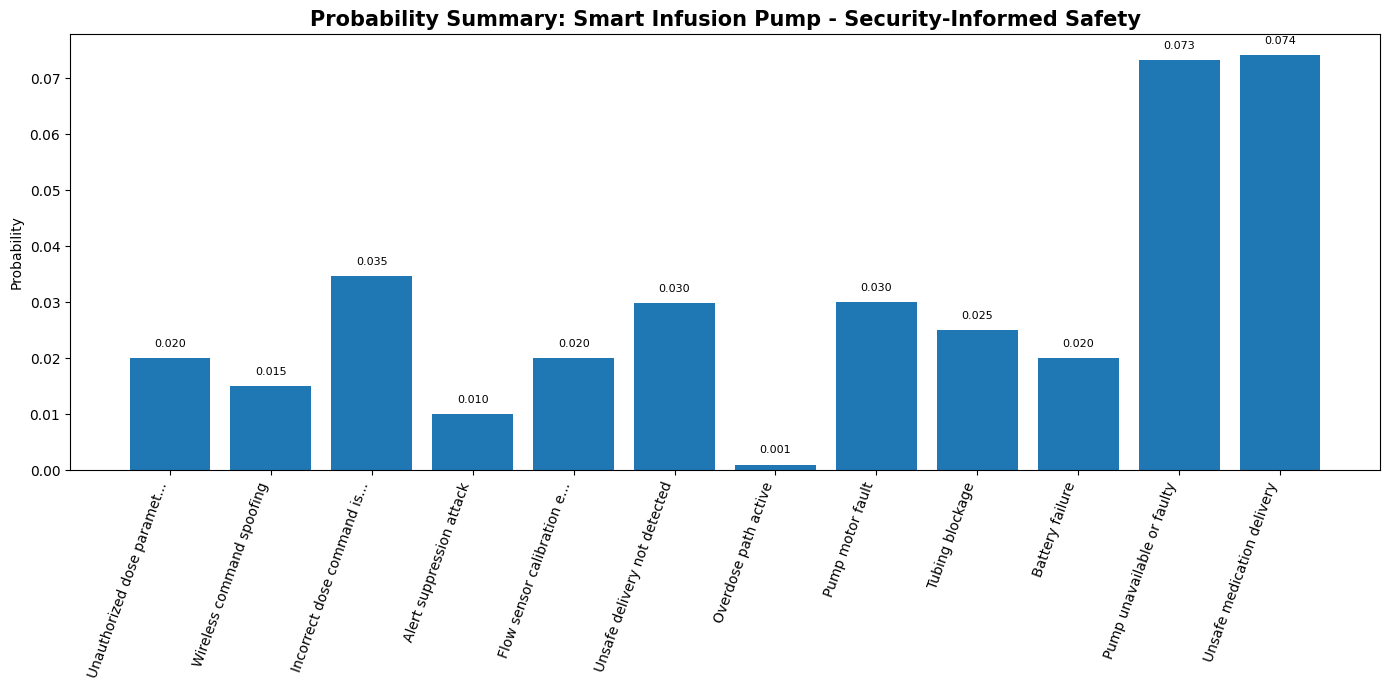


------------------------------------------------------------------------------------------
MOCUS - All Cut Sets
------------------------------------------------------------------------------------------
Set No.    Order    Cut Set
------------------------------------------------------------------------------------------
1          2        {Alert suppression attack, Unauthorized dose parameter change}
2          2        {Flow sensor calibration error, Unauthorized dose parameter change}
3          2        {Alert suppression attack, Wireless command spoofing}
4          2        {Flow sensor calibration error, Wireless command spoofing}
5          1        {Pump motor fault}
6          1        {Tubing blockage}
7          1        {Battery failure}

------------------------------------------------------------------------------------------
MOCUS - Minimal Cut Sets
------------------------------------------------------------------------------------------
Set No.    Order    Cut Set
--

In [25]:
# Create the case study root node
infusion_root = build_infusion_pump_case()

# Run the full analysis
infusion_results = run_case_study(
    infusion_root,
    "Smart Infusion Pump - Security-Informed Safety"
)

# Conclusion

 This case study demonstrates how Fault Tree Analysis can be used to model a Smart Infusion Pump where both cyber threats and physical system faults contribute to unsafe medication delivery.

 The use of both MOCUS and MICSUP helps verify the correctness of the minimal cut sets. The gate-by-gate probability calculation also providesa quantitative understanding of how individual events propagate upward to the top event.

 Overall, this example shows that safety analysis can be strengthened by explicitly including cybersecurity-related failures within the same model.